# EX6 ANN MNIST

In [1]:
import torchvision
import torch
import torch.nn as nn
import torch.optim as opt
from matplotlib import pyplot as plt
import numpy as np
from torchvision.transforms import transforms

## data preparation

In [2]:
train_dataset = torchvision.datasets.MNIST("../DATA/",download=True,train=True,transform=transforms.ToTensor())
test_dataset = torchvision.datasets.MNIST("../DATA/",download=True,train=False,transform=transforms.ToTensor())


let's visualize

Text(0.5, 1.0, '5')

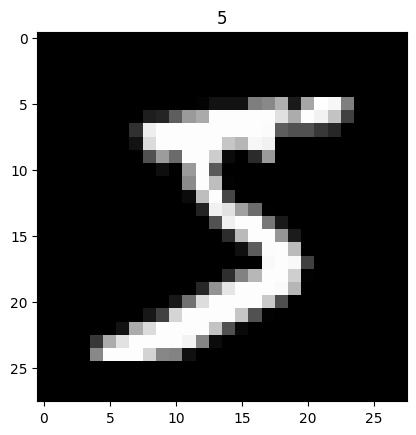

In [3]:
plt.imshow(train_dataset.data[0],cmap='gray')
plt.title(str(train_dataset.targets[0].item()))


data processing continued

In [4]:
print(f'train x shape {train_dataset.data.shape} y_train {train_dataset.targets.shape}\ntest x shape {test_dataset.data.shape} y_test {test_dataset.targets.shape}')

train x shape torch.Size([60000, 28, 28]) y_train torch.Size([60000])
test x shape torch.Size([10000, 28, 28]) y_test torch.Size([10000])


In [5]:
train_loader = torch.utils.data.DataLoader(dataset=train_dataset,batch_size=128,shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset,batch_size=128,shuffle=False)

## build the model

In [6]:
model = nn.Sequential(
    nn.Linear(28*28,128),
    nn.ReLU(),
    nn.Linear(128,10)
    # nn.Softmax() - not needed 
)

## set device to GPU(if exists)

In [7]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)
model.to(device=device)

cuda:0


Sequential(
  (0): Linear(in_features=784, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=10, bias=True)
)

In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = opt.Adam(model.parameters(),lr=0.0001)

## Training the model

In [9]:
EPOCHS = 10
train_losses = []
test_losses = []
train_accuracy = []
test_accuracy = []

for epoch in range(EPOCHS): 
    n_correct = 0
    n_total = 0
    train_loss = []
    # 0. batch loop 
    for inputs,targets in train_loader:
        #1. zero gradients  that optimizer are in charge
        optimizer.zero_grad()
        
        # put inputs and targets into device(GPU)
        inputs,targets = inputs.to(device),targets.to(device)

        # flatten the input (because it's ANN NxD)
        inputs = inputs.view(-1,28*28)

        outputs = model(inputs)

        loss = criterion(outputs,targets)
        loss.backward()
        optimizer.step()
        _,indxs = torch.max(outputs,1)
        
        #calculate accuracy
       
        n_total += indxs.shape[0]
        n_correct += (indxs == targets).sum().item()
        #batch loss
        train_loss.append(loss.item())

    train_losses.append(np.mean(train_loss))
    train_accuracy.append(n_correct/n_total)
    test_loss = []
    #test
    n_correct = 0
    n_total = 0
    for inputs,targets in test_loader:
        inputs,targets = inputs.to(device),targets.to(device)
        inputs = inputs.view(-1,28*28)

        outputs = model(inputs)
        loss = criterion(outputs,targets)
        test_loss.append(loss.item())
        _,indxs = torch.max(outputs,1)

    #calculate accuracy
 
    n_total += indxs.shape[0]
    n_correct += (indxs == targets).sum().item()
    test_losses.append(np.mean(test_loss))
    test_accuracy.append(n_correct/n_total)


    print(f'train_loss {train_losses[-1]} test_loss {test_losses[-1]} train acc: {train_accuracy[-1]} test acc: {test_accuracy[-1]}')
    #acc = n_correct /n_total

train_loss 1.1836856587100892 test_loss 0.5638954530033884 train acc: 0.7612666666666666 test acc: 0.75
train_loss 0.4687130150001949 test_loss 0.3787458104234708 train acc: 0.8857166666666667 test acc: 0.875
train_loss 0.3634479501163527 test_loss 0.3240802774700937 train acc: 0.90255 test acc: 0.9375
train_loss 0.3214117794720603 test_loss 0.29493913502444197 train acc: 0.9116666666666666 test acc: 0.9375
train_loss 0.29579953833429545 test_loss 0.2752026895980669 train acc: 0.9174333333333333 test acc: 0.9375
train_loss 0.27635818209920104 test_loss 0.2601656144649922 train acc: 0.9224166666666667 test acc: 0.9375
train_loss 0.26013359006470455 test_loss 0.24776296791490876 train acc: 0.9277333333333333 test acc: 0.9375
train_loss 0.24624286989159166 test_loss 0.23506600908416359 train acc: 0.931 test acc: 0.9375
train_loss 0.23295544537463422 test_loss 0.2241445760584519 train acc: 0.9346666666666666 test acc: 0.9375
train_loss 0.2211138632601258 test_loss 0.21424135205017614 train

In [10]:
#predict:

# _,predictions = torch.max(outputs,1)

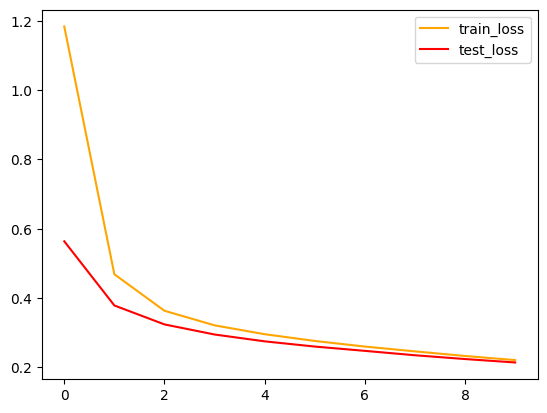

In [11]:
x = [i for i in range(EPOCHS)]
plt.plot(x,train_losses,label='train_loss',color='orange')
plt.plot(x,test_losses,label='test_loss',color='red')
plt.legend()

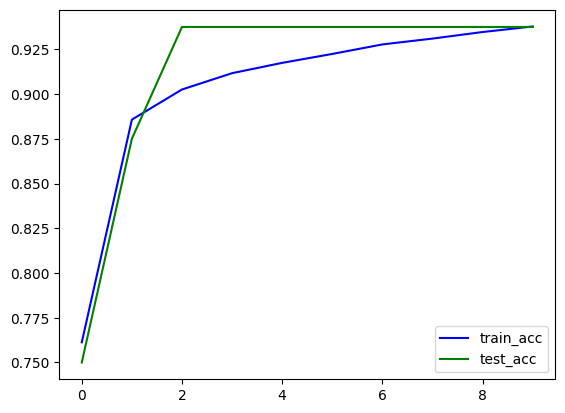

In [12]:
x = [i for i in range(EPOCHS)]
plt.plot(x,train_accuracy,label='train_acc',color='blue')
plt.plot(x,test_accuracy,label='test_acc',color='green')
plt.legend()

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [14]:
y= []
y_hat = []
for inputs,outputs in test_loader:
    inputs,outputs = inputs.to(device),outputs.to(device)
    inputs= inputs.view(-1,28*28)
    predict = model(inputs)
    _,predict = torch.max(predict,1)
    y = np.concatenate((y,outputs.cpu().numpy()))
    y_hat = np.concatenate((y_hat,predict.cpu().numpy()))


In [15]:
test_dataset.classes

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

In [16]:
cm = confusion_matrix(y_true=y,y_pred=y_hat)

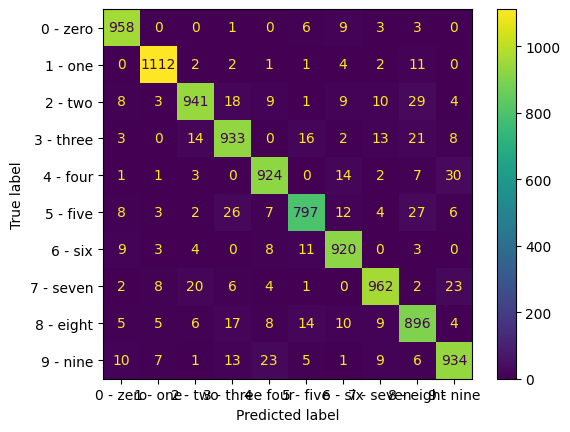

In [17]:
ConfusionMatrixDisplay.from_predictions(y_true=y,y_pred=y_hat,display_labels=test_dataset.classes)

In [ ]:
misclassified_idx = np.where(y_hat != y)[0] #array inside array
misclassified_idx

(array([   8,   33,   92,  149,  193,  195,  217,  233,  241,  247,  259,
         290,  300,  318,  320,  321,  340,  352,  362,  381,  412,  444,
         445,  448,  464,  478,  479,  502,  507,  511,  531,  543,  551,
         565,  569,  578,  582,  591,  613,  619,  628,  629,  659,  684,
         691,  707,  717,  720,  728,  740,  760,  791,  839,  844,  877,
         881,  882,  898,  924,  938,  939,  947,  950,  951,  956,  959,
         965,  975,  982, 1003, 1014, 1032, 1039, 1044, 1062, 1068, 1073,
        1082, 1096, 1101, 1107, 1112, 1114, 1128, 1173, 1181, 1182, 1191,
        1192, 1194, 1198, 1204, 1206, 1226, 1228, 1232, 1234, 1242, 1247,
        1256, 1260, 1283, 1289, 1299, 1319, 1325, 1326, 1328, 1337, 1364,
        1378, 1393, 1410, 1429, 1433, 1440, 1444, 1465, 1467, 1494, 1500,
        1522, 1525, 1527, 1530, 1549, 1553, 1559, 1581, 1609, 1621, 1634,
        1678, 1681, 1709, 1717, 1722, 1751, 1754, 1772, 1773, 1774, 1790,
        1800, 1828, 1850, 1865, 1868, 

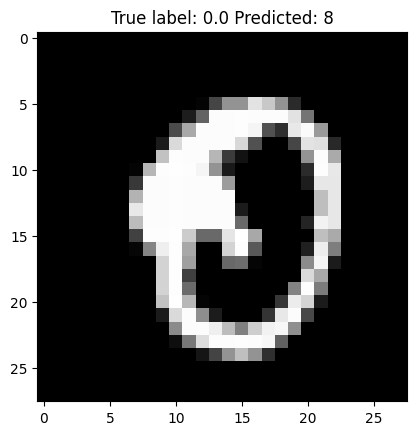

In [21]:
# Show some misclassified examples
misclassified_idx = np.where(y_hat != y)[0]
i = np.random.choice(misclassified_idx)
plt.imshow(test_dataset.data[i], cmap='gray')
plt.title("True label: %s Predicted: %s" % (y[i], int(y_hat[i])));